# Exercise 9:

In [47]:
import numpy as np
from sklearn.datasets import fetch_openml
import numpy as np
mnist = fetch_openml('mnist_784', version = 1)
X, y = mnist['data'].to_numpy(), mnist['target'].to_numpy().astype(np.uint8)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [32]:

from sklearn.ensemble import RandomForestClassifier
random_forest_classifier = RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 5, n_jobs = -1)
random_forest_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1)

In [33]:
from sklearn.metrics import accuracy_score
y_pred = random_forest_classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.9496

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 0.95)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

In [35]:
X_train_reduced.shape #154 components remained

(60000, 154)

In [36]:
random_forest_classifier2 = RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 5, n_jobs = -1)

random_forest_classifier2.fit(X_train_reduced, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_jobs=-1)

In [37]:
y_pred = random_forest_classifier2.predict(X_test_reduced)
accuracy_score(y_test, y_pred)

0.9171

# Exercise 10:

In [38]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2)
X_reduced = tsne.fit_transform(X)

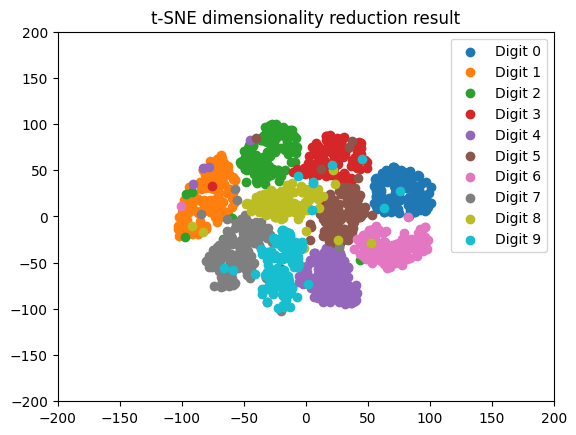

In [61]:
from matplotlib import pyplot as plt

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive',
    'tab:cyan'
]

fig, ax = plt.subplots()
instances_to_plot = 1500
tsne_x = X_reduced[:instances_to_plot]
tsne_y = y[:instances_to_plot]

for i, color in enumerate(colors):
    plt.scatter(tsne_x[tsne_y == i, 0], tsne_x[tsne_y == i, 1], color = color, label = f'Digit {i}')
ax.legend(loc = 'best')
ax.set_xlim(-200, 200)
ax.set_ylim(-200, 200)
ax.set_title('t-SNE dimensionality reduction result')
plt.show()